# 데이터 불러오기

In [15]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (22.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125082 files and direc

In [ ]:
# 📌 하는 일: 필요한 라이브러리들 임포트
# 🎯 목적: 딥러닝 모델 구축과 데이터 처리를 위한 필수 도구들 준비
import pandas as pd  # 데이터 처리 및 분석 라이브러리
import numpy as np   # 수치 계산 라이브러리
import matplotlib.pyplot as plt  # 데이터 시각화 라이브러리
import torch  # PyTorch 딥러닝 프레임워크
import torch.nn as nn  # PyTorch 신경망 모듈
from torch.utils.data import Dataset, DataLoader  # 데이터셋 및 데이터로더 클래스

# 📌 하는 일: SMS Spam 데이터셋 다운로드 및 로드
# 🎯 목적: 스팸 메시지 분류를 위한 벤치마크 데이터셋 준비
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"  # 데이터셋 URL
df = pd.read_table(url, header=None, names=['label', 'message'])  # TSV 파일 읽기:
                                                                  # - header=None: 첫 행이 헤더가 아님
                                                                  # - names=['label', 'message']: 컬럼 이름 지정

# 📌 하는 일: 데이터프레임 인덱스 초기화
# 🎯 목적: 깔끔한 인덱스로 재정렬하여 데이터 접근 용이하게 함
df = df.reset_index(drop=True)  # 기존 인덱스를 제거하고 0부터 시작하는 새 인덱스 생성

# 📌 하는 일: 데이터셋 기본 정보 확인
# 🎯 목적: 데이터 크기와 구조를 파악하여后续 작업 준비
print("데이터셋 크기:", df.shape)  # (행 개수, 열 개수) 출력
df.head()  # 처음 5개 행 출력하여 데이터 미리보기

데이터셋 크기: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!nvidia-smi

Wed Nov  5 02:37:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 데이터 분할

In [ ]:
# 📌 하는 일: 머신러닝 모델 평가를 위한 데이터 분할 함수 임포트
# 🎯 목적: 데이터를 훈련 세트와 테스트 세트로 분할하여 모델 성능을 정확하게 평가하기 위함
from sklearn.model_selection import train_test_split  # scikit-learn의 데이터 분할 모듈
                                                     # train_test_split: 데이터를 무작위로 훈련/테스트 세트로 분할

# 📌 하는 일: 자연어 처리 토큰화 도구 임포트
# 🎯 목적: 텍스트를 개별 단어(토큰)로 분리하기 위한 도구 준비
from nltk.tokenize import word_tokenize  # NLTK의 단어 토큰화 함수
                                        # 문장을 단어 단위로 분리 (예: "I love AI" → ["I", "love", "AI"])

# 📌 하는 일: NLTK 라이브러리 임포트
# 🎯 목적: 자연어 처리 작업을 위한 포괄적인 도구 모음
import nltk  # Natural Language Toolkit - 자연어 처리 라이브러리

# 📌 하는 일: NLTK 토큰화에 필요한 데이터 패키지 다운로드
# 🎯 목적: word_tokenize 함수가 제대로 작동하기 위해 필요한 학습 데이터 다운로드
nltk.download('punkt')  # 문장 토큰화(sentence tokenization)용 데이터 패키지 다운로드
                       # 영어 텍스트를 단어와 문장으로 분리하는데 필요한 규칙 데이터

nltk.download('punkt_tab')  # 향상된 토큰화 모델 다운로드 (NLTK 최신 버전)
                           # 더 정확한 토큰화를 제공하는 트랜스포머 기반 모델

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# 📌 하는 일: 레이블을 숫자로 변환 (인코딩)
# 🎯 목적: 머신러닝 모델이 이해할 수 있는 수치형 레이블로 변환
df['label'] = df['label'].map({'ham':0, 'spam': 1})  # 문자열 레이블을 숫자로 매핑:
                                                    # - 'ham' → 0 (정상 메시지)
                                                    # - 'spam' → 1 (스팸 메시지)
                                                    # 이진 분류 문제로 변환

# 📌 하는 일: 텍스트와 레이블을 리스트 형태로 추출
# 🎯 목적: 모델 학습에 적합한 데이터 형식으로 변환
texts, labels = df['message'].tolist(), df['label'].tolist()  # pandas Series를 Python 리스트로 변환:
                                                             # - texts: 모든 메시지 내용의 리스트
                                                             # - labels: 모든 레이블의 리스트

# 📌 하는 일: 데이터를 훈련 세트와 테스트 세트로 분할
# 🎯 목적: 모델 성능을公正하게 평가하기 위해 데이터 분리
train_inputs, test_inputs, train_targets, test_targets = train_test_split(
    df['message'],  # 입력 특징 (메시지 텍스트)
    df['label'],    # 타겟 레이블 (0 또는 1)
    test_size=0.2,  # 테스트 세트 비율 (20%)
    random_state=42 # 재현성을 위한 랜덤 시드 (동일한 분할 유지)
)

# 📌 하는 일: Series를 리스트로 변환하여 인덱스 문제 해결
# 🎯 목적: PyTorch Dataset에서 인덱싱 문제를 방지하기 위해 명시적 변환
train_inputs_list = train_inputs.tolist()  # 훈련 입력 데이터를 리스트로 변환
train_targets_list = train_targets.tolist()  # 훈련 타겟 데이터를 리스트로 변환
test_inputs_list = test_inputs.tolist()  # 테스트 입력 데이터를 리스트로 변환
test_targets_list = test_targets.tolist()  # 테스트 타겟 데이터를 리스트로 변환

# 📌 하는 일: 데이터셋 기본 정보 출력
# 🎯 목적: 데이터 크기와 샘플 내용을 확인하여 전처리 상태 점검
print(f"Number of documents: {len(texts)}")  # 전체 문서 개수 출력
print(f"Sample documents: \n{texts[0]}")  # 첫 번째 문서 샘플 출력

Number of documents: 5572
Sample documents: 
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


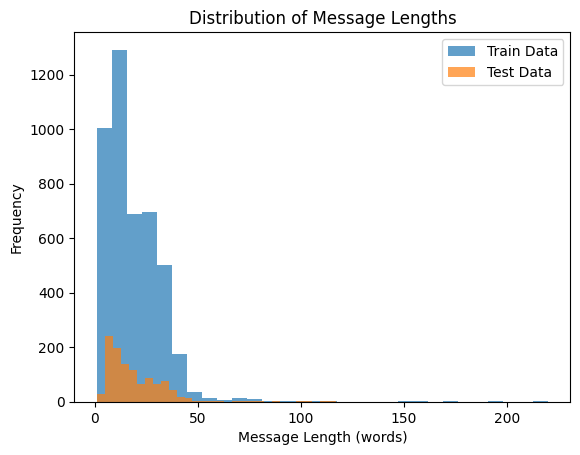

훈련 데이터 평균 길이: 18.85304016154364
훈련 데이터 최대 길이: 220
훈련 데이터 중간값: 18.85304016154364


In [ ]:
# 메시지 길이 분포 확인
train_lengths = [len(word_tokenize(msg)) for msg in train_inputs]
test_lengths = [len(word_tokenize(msg)) for msg in test_inputs]

plt.hist(train_lengths, bins=30, alpha=0.7, label='Train Data')
plt.hist(test_lengths, bins=30, alpha=0.7, label='Test Data')
plt.xlabel('Message Length (words)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Message Lengths')
plt.show()


# 평균 및 최대 길이 확인
print(f"훈련 데이터 평균 길이: {np.mean(train_lengths)}")
print(f"훈련 데이터 최대 길이: {np.max(train_lengths)}")
print(f"훈련 데이터 중간값: {np.mean(train_lengths)}")



# Word2Vec

https://wikidocs.net/50739


In [ ]:
# 📌 하는 일: 훈련 및 테스트 데이터를 단어 단위로 토큰화
# 🎯 목적: 텍스트를 개별 단어로 분리하여 Word2Vec 모델 학습에 적합한 형태로 변환
train_sentences = [word_tokenize(msg) for msg in train_inputs]  # 훈련 메시지들을 단어 단위로 분리
                                                               # 예: "hello world" → ["hello", "world"]
test_sentences = [word_tokenize(msg) for msg in test_inputs]   # 테스트 메시지들을 단어 단위로 분리


In [ ]:
# 📌 하는 일: gensim 라이브러리 설치
# 🎯 목적: Word2Vec 모델 학습을 위한 라이브러리 설치
!pip install gensim  # Python 패키지 관리자를 통해 gensim 라이브러리 설치
                    # Word2Vec, FastText 등 단어 임베딩 모델 제공


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.3 MB/s eta 0:00:00


In [ ]:
# 📌 하는 일: Word2Vec 모델 클래스 임포트
# 🎯 목적: 단어 임베딩 모델을 생성하고 학습하기 위해 필요한 클래스 가져오기
from gensim.models import Word2Vec  # gensim 라이브러리의 Word2Vec 모델

# 📌 하는 일: Word2Vec 모델 학습
# 🎯 목적: 토큰화된 문장들을 기반으로 단어 임베딩 모델 학습
word2vec_model = Word2Vec(
    train_sentences,     # 학습 데이터 (토큰화된 문장들의 리스트)
    vector_size=50,      # 임베딩 벡터의 차원 (50차원)
    window=5,            # 주변 단어 윈도우 크기 (주변 5개 단어 고려)
    min_count=1,         # 최소 단어 빈도 (1번만 등장해도 학습)
    sg=1                 # 학습 알고리즘 (1: Skip-gram, 0: CBOW)
)

# 📌 하는 일: 단어 임베딩 행렬 초기화
# 🎯 목적: PyTorch 임베딩 레이어에 사용할 수 있는 형태로 행렬 준비
word2vec_matrix = np.zeros((len(word2vec_model.wv) + 1, 50))  # 0으로 채워진 행렬 생성:
                                                              # - 행: 단어 개수 + 1 (패딩 인덱스 0을 위해)
                                                              # - 열: 50 (임베딩 차원)

# 📌 하는 일: 단어-인덱스 매핑 딕셔너리 생성
# 🎯 목적: 각 단어에 고유 인덱스를 부여하여 숫자로 변환
word2idx_word2vec = {word: idx + 1 for idx, word in enumerate(word2vec_model.wv.index_to_key)}
# 단어를 키로, 인덱스+1을 값으로 하는 딕셔너리 생성
# 인덱스는 1부터 시작 (0은 패딩용으로 예약)

# 📌 하는 일: 임베딩 행렬에 Word2Vec 벡터 값 채우기
# 🎯 목적: 학습된 Word2Vec 임베딩 값을 행렬에 저장하여 PyTorch에서 사용 가능하게 함
for word, idx in word2idx_word2vec.items():  # 모든 단어와 인덱스 쌍에 대해 반복
    word2vec_matrix[idx] = word2vec_model.wv[word]  # 해당 인덱스의 행에 Word2Vec 벡터 값 할당

In [ ]:
# 📌 하는 일: 'he' 단어의 Word2Vec 임베딩 벡터 확인
# 🎯 목적: 특정 단어가 어떻게 50차원 벡터로 표현되었는지 실제 값 확인
vector = word2vec_model.wv['he']  # 'he' 단어의 50차원 임베딩 벡터 추출
print(vector)  # 벡터 값 출력

# 📌 하는 일: 'he' 단어와 가장 유사한 단어 5개 찾기
# 🎯 목적: Word2Vec이 학습한 단어 간 의미적 관계 확인
s_vector = word2vec_model.wv.most_similar('he', topn=5)  # 'he'와 가장 유사한 상위 5개 단어 찾기
                                                         # 코사인 유사도 기준으로 정렬
print(s_vector)  # 유사 단어와 유사도 점수 출력

# 📌 하는 일: 'he'과 'man' 단어 간 유사도 계산
# 🎯 목적: 두 특정 단어 간의 의미적 유사성을 수치화
s_vector_cal = word2vec_model.wv.similarity('he', 'man')  # 'he'와 'man'의 코사인 유사도 계산
print(s_vector_cal)  # 유사도 점수 출력 (0~1 사이 값)

[ 0.00720061 -0.13361672 -0.5172235   0.14899777 -0.28508654 -0.46060053
  0.36542854  0.8420569  -0.30697808  0.27160236 -0.1798773  -0.7958482
  0.07454928  0.42463508 -0.23251936  0.16031477  0.04045956  0.24201612
 -0.561516   -0.14316231  0.03750222  0.09216977  0.76379544 -0.01150792
  0.27844223 -0.0876124  -0.2720566   0.5404322  -0.6041862  -0.18424162
 -0.1897566  -0.39958423 -0.5080361  -0.47896603 -0.43469524  0.35907072
  0.5386221  -0.07888577  0.11991932  0.15516356  0.01492787 -0.31100595
 -0.32932383  0.4134716   1.1647805   0.24232996 -0.03879749 -0.27304575
 -0.10087016  0.16314971]
[('she', 0.9758604168891907), ('time', 0.9736021757125854), ('Yeah', 0.9674118161201477), ('one', 0.9672242999076843), ('sure', 0.9663087129592896)]
0.9213229


In [ ]:
class WordSpamDataset(Dataset):
    """텍스트 문장을 토큰화, 정수 인코딩, 패딩/절단을 거쳐 지정된 길이(max_len)의 텐서로 변환하는 스팸 데이터셋"""

    def __init__(self, texts, labels, word2idx, max_len):
        # 📌 하는 일: 데이터셋 초기화
        # 🎯 목적: 데이터와 변환 파라미터를 저장하여 데이터 샘플링 준비
        self.texts = texts        # 원본 텍스트 데이터 리스트
        self.labels = labels      # 레이블 데이터 리스트 (0: ham, 1: spam)
        self.word2idx = word2idx  # 단어-인덱스 매핑 딕셔너리
        self.max_len = max_len    # 최대 시퀀스 길이 (패딩/절단 기준)

    def __len__(self):
        # 📌 하는 일: 데이터셋의 총 샘플 수 반환
        # 🎯 목적: DataLoader가 데이터 크기를 알 수 있게 함
        return len(self.texts)  # 텍스트 개수 반환

    def __getitem__(self, idx):
        # 📌 하는 일: 특정 인덱스의 데이터 샘플을 변환하여 반환
        # 🎯 목적: 모델이 처리할 수 있는 형식으로 개별 데이터 포인트 변환

        # 1. 텍스트 토큰화
        tokens = word_tokenize(self.texts[idx])  # 텍스트를 단어 단위로 분리

        # 2. 정수 인코딩 (단어 → 숫자 인덱스)
        encoded = [self.word2idx.get(word, 0) for word in tokens]  # 각 단어를 인덱스로 변환:
                                                                  # - word2idx에 있는 단어: 해당 인덱스
                                                                  # - 없는 단어(OOV): 0 (패딩/알수없음)

        # 3. 패딩 또는 절단 (고정 길이 시퀀스로 변환)
        if len(encoded) < self.max_len:
            # 패딩: 시퀀스가 max_len보다 짧으면 0으로 채움
            encoded += [0] * (self.max_len - len(encoded))
        else:
            # 절단: 시퀀스가 max_len보다 길면 앞부분 자름
            encoded = encoded[:self.max_len]

        # 4. PyTorch 텐서로 변환 및 반환
        return (
            torch.tensor(encoded, dtype=torch.long),    # 입력 특성 텐서 (정수형)
            torch.tensor(self.labels[idx], dtype=torch.float)  # 타겟 레이블 텐서 (실수형)
        )

In [ ]:
class EmbeddingLSTM(nn.Module):
    """사전 학습된 임베딩과 LSTM을 사용하여 텍스트를 이진 분류하는 모델"""

    def __init__(self, embedding_matrix, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        # 📌 하는 일: LSTM 모델 초기화
        # 🎯 목적: 네트워크 아키텍처 정의 및 레이어 생성
        super(EmbeddingLSTM, self).__init__()  # 부모 클래스 nn.Module 초기화

        # 임베딩 레이어 정보 추출
        num_embeddings, embedding_dim = embedding_matrix.shape

        # 1. 사전 학습된 임베딩 레이어 생성
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float).to(device),  # Word2Vec 행렬을 텐서로 변환
            freeze=False  # 미세 조정 허용 (학습 동안 임베딩 업데이트)
        )

        # 2. LSTM 레이어 생성
        self.lstm = nn.LSTM(
            embedding_dim,      # 입력 차원 (임베딩 차원)
            hidden_dim,         # 은닉 상태 차원
            num_layers=num_layers,  # LSTM 층 수
            batch_first=True,   # 입력 형식: (batch, seq, feature)
            dropout=dropout     # 과적합 방지를 위한 드롭아웃
        )

        # 3. 완전 연결 레이어 (분류기)
        self.fc = nn.Linear(hidden_dim, output_dim)  # LSTM 출력 → 이진 분류

    def forward(self, x):
        # 📌 하는 일: 순전파 계산 정의
        # 🎯 목적: 입력 데이터를 통해 예측값 계산

        # 1. 임베딩 레이어 통과
        embedded = self.embedding(x)  # (batch, seq_len) → (batch, seq_len, embedding_dim)

        # 2. LSTM 레이어 통과
        _, (hidden, _) = self.lstm(embedded)  # LSTM 출력에서 마지막 hidden state 추출
        # hidden: (num_layers, batch, hidden_dim)

        # 3. 마지막 LSTM 층의 hidden state 사용
        output = self.fc(hidden[-1])  # (batch, hidden_dim) → (batch, output_dim)

        # 4. 시그모이드 활성화 함수 적용 (이진 분류)
        return torch.sigmoid(output)  # 0~1 사이의 확률값 출력

In [ ]:
# 📌 하는 일: 모델 하이퍼파라미터 정의
# 🎯 목적: 모델 구조와 학습을 위한 주요 설정값 지정
embedding_dim = 50    # Word2Vec 임베딩 차원 (50차원)
max_len = 50          # 최대 시퀀스 길이 (50개 단어)
hidden_dim = 128      # LSTM 은닉 상태 차원
output_dim = 1        # 출력 차원 (이진 분류: 1개 뉴런)

In [ ]:
# 📌 하는 일: WordSpamDataset 생성
# 🎯 목적: 훈련 및 테스트 데이터를 모델이 사용할 수 있는 형식으로 변환
train_dataset_word2vec = WordSpamDataset(
    train_inputs_list,      # 훈련 텍스트 데이터
    train_targets_list,     # 훈련 레이블
    word2idx_word2vec,      # Word2Vec 단어-인덱스 매핑
    max_len                 # 최대 시퀀스 길이
)

test_dataset_word2vec = WordSpamDataset(
    test_inputs_list,       # 테스트 텍스트 데이터
    test_targets_list,      # 테스트 레이블
    word2idx_word2vec,      # Word2Vec 단어-인덱스 매핑
    max_len                 # 최대 시퀀스 길이
)

# 📌 하는 일: DataLoader 생성
# 🎯 목적: 배치 처리, 셔플, 병렬 로딩을 통해 효율적인 데이터 공급
train_loader_word2vec = DataLoader(
    train_dataset_word2vec,
    batch_size=32,      # 한 번에 처리할 샘플 수
    shuffle=True        # 에포크마다 데이터 순서 무작위화 (과적합 방지)
)

test_loader_word2vec = DataLoader(
    test_dataset_word2vec,
    batch_size=32,      # 테스트时 동일한 배치 크기
    shuffle=False       # 테스트时 순서 유지 (일관된 평가)
)

In [ ]:
def train(model, loader, criterion, optimizer):
    """모델을 1 epoch 동안 학습시키는 함수"""
    # 📌 하는 일: 모델을 학습 모드로 설정
    # 🎯 목적: 드롭아웃 등의 학습 시만 사용하는 레이어들을 활성화
    model.train()
    total_loss = 0

    # 📌 하는 일: 데이터로더에서 배치 단위로 데이터 반복 처리
    # 🎯 목적: 전체 데이터를 작은 배치로 나누어 메모리 효율적으로 학습
    for texts, labels in loader:
        # 1. 데이터를 GPU로 이동 (가속화)
        texts, labels = texts.to(device), labels.to(device)

        # 2. 레이블 차원 조정 (batch_size) → (batch_size, 1)
        labels = labels.unsqueeze(1)  # BCELoss가 요구하는 형식으로 변환

        # 3. 그래디언트 초기화
        optimizer.zero_grad()  # 이전 배치의 그래디언트를 초기화 (중복 계산 방지)

        # 4. 순전파 (Forward Pass): 모델 예측 계산
        outputs = model(texts)  # 모델 출력: (batch_size, 1) 형태의 확률값

        # 5. 손실 계산
        loss = criterion(outputs, labels)  # BCELoss: 예측값과 실제 레이블 간의 차이 계산

        # 6. 역전파 (Backward Pass): 그래디언트 계산
        loss.backward()  # 각 파라미터에 대한 손실의 그래디언트 계산

        # 7. 옵티마이저 스텝: 파라미터 업데이트
        optimizer.step()  # 계산된 그래디언트를 사용하여 모델 파라미터 업데이트

        # 8. 배치 손실 누적
        total_loss += loss.item()  # 현재 배치의 손실값을 총합에 추가

    # 📌 하는 일: 에포크 평균 손실 반환
    # 🎯 목적: 학습 진행 상황 모니터링
    return total_loss / len(loader)  # 전체 배치 수로 나누어 평균 손실 계산

def evaluate(model, loader):
    """모델의 성능(정확도)을 평가하는 함수"""
    # 📌 하는 일: 모델을 평가 모드로 설정
    # 🎯 목적: 드롭아웃 등의 레이어를 비활성화하여 일관된 평가
    model.eval()
    correct, total = 0, 0  # 정답 개수와 전체 개수 초기화

    # 📌 하는 일: 그래디언트 계산 비활성화 (메모리 절약)
    # 🎯 목적: 평가 시에는 파라미터 업데이트가 필요없으므로 그래디언트 계산 생략
    with torch.no_grad():
        for texts, labels in loader:
            # 1. 데이터를 GPU로 이동
            texts, labels = texts.to(device), labels.to(device)

            # 2. 레이블 차원 조정 및 타입 변환
            labels = labels.unsqueeze(1).float()  # (batch_size, 1) 형태로 변환

            # 3. 모델 예측
            outputs = model(texts)  # (batch_size, 1) 형태의 확률값 출력

            # 4. 확률값을 이진 예측으로 변환 (0.5 기준)
            predictions = (outputs >= 0.5).float()  # 0.5 이상이면 1(스팸), 미만이면 0(햄)

            # 5. 정답 개수 계산
            correct += (predictions == labels).sum().item()  # 예측과 실제가 일치하는 개수 누적

            # 6. 전체 데이터 개수 누적
            total += labels.size(0)  # 현재 배치의 데이터 개수 추가

    # 📌 하는 일: 정확도 계산 및 반환
    # 🎯 목적: 모델의 전체적인 성능 평가
    return correct / total  # 정확도 = 정답 개수 / 전체 개수

In [ ]:
# 📌 하는 일: Word2Vec+LSTM 모델 초기화
# 🎯 목적: 사전 학습된 Word2Vec 임베딩을 사용하는 LSTM 모델 생성
model_word2vec = EmbeddingLSTM(word2vec_matrix, hidden_dim, output_dim).to(device)
# - word2vec_matrix: 사전 학습된 Word2Vec 임베딩 행렬
# - hidden_dim: 128 (LSTM 은닉 상태 차원)
# - output_dim: 1 (이진 분류 출력)
# - .to(device): 모델을 GPU로 이동 (가속화)

# 📌 하는 일: 손실 함수 정의
# 🎯 목적: 모델의 예측과 실제 값 간의 차이를 측정하는 기준 설정
loss_fn = nn.BCELoss()  # Binary Cross Entropy Loss (이진 분류용)
# - 출력값이 0~1 사이의 확률일 때 적합
# - 스팸(1) vs 햄(0) 분류에 최적화

# 📌 하는 일: 옵티마이저 정의
# 🎯 목적: 모델 파라미터를 업데이트하는 최적화 알고리즘 설정
optimizer = torch.optim.Adam(model_word2vec.parameters(), lr=0.001)
# - Adam: 적응형 학습률을 사용하는 인기 있는 옵티마이저
# - model_word2vec.parameters(): 업데이트할 모델 파라미터들
# - lr=0.001: 학습률 (파라미터 업데이트 크기)

In [ ]:
# 📌 하는 일: 10에포크 동안 모델 학습 실행
# 🎯 목적: 반복적인 학습을 통해 모델 성능 향상
for epoch in range(10):
    # 1. 한 에포크 학습 및 손실 계산
    loss = train(model_word2vec, train_loader_word2vec, loss_fn, optimizer)

    # 2. 학습 진행 상황 출력
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 📌 하는 일: 최종 모델 성능 평가
# 🎯 목적: 학습된 모델의 실제 성능을 테스트 데이터로 측정
accuracy = evaluate(model_word2vec, test_loader_word2vec)
print(f"Test Accuracy (Word2Vec with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 0.4080
Epoch 2, Loss: 0.3888
Epoch 3, Loss: 0.2924
Epoch 4, Loss: 0.1884
Epoch 5, Loss: 0.0823
Epoch 6, Loss: 0.0413
Epoch 7, Loss: 0.0318
Epoch 8, Loss: 0.0200
Epoch 9, Loss: 0.0185
Epoch 10, Loss: 0.0134
Test Accuracy (Word2Vec with LSTM): 0.9901


# FastText


In [ ]:
from gensim.models import FastText  # FastText 모델 임포트

# 📌 하는 일: FastText 모델 학습
# 🎯 목적: 서브워드 정보를 활용한 향상된 단어 임베딩 모델 생성
fasttext_model = FastText(
    sentences=train_sentences,  # 학습 데이터 (토큰화된 훈련 문장들)
    vector_size=50,             # 임베딩 벡터 차원 (50차원)
    window=5,                   # 주변 단어 윈도우 크기 (주변 5개 단어)
    min_count=1,                # 최소 단어 빈도 (1번만 등장해도 학습)
    sg=1                        # 학습 알고리즘 (1: Skip-gram, 0: CBOW)
)

# 📌 하는 일: FastText 임베딩 행렬 초기화
# 🎯 목적: PyTorch 임베딩 레이어에 사용할 수 있는 형태로 행렬 준비
fasttext_matrix = np.zeros((len(fasttext_model.wv) + 1, 50))  # 0으로 채워진 행렬 생성:
                                                              # - 행: 단어 개수 + 1 (패딩 인덱스 0을 위해)
                                                              # - 열: 50 (임베딩 차원)

# 📌 하는 일: FastText 단어-인덱스 매핑 딕셔너리 생성
# 🎯 목적: 각 단어에 고유 인덱스를 부여하여 숫자로 변환
word2idx_fasttext = {word: idx + 1 for idx, word in enumerate(fasttext_model.wv.index_to_key)}
# 단어를 키로, 인덱스+1을 값으로 하는 딕셔너리 생성
# 인덱스는 1부터 시작 (0은 패딩용으로 예약)

# 📌 하는 일: 임베딩 행렬에 FastText 벡터 값 채우기
# 🎯 목적: 학습된 FastText 임베딩 값을 행렬에 저장
for word, idx in word2idx_fasttext.items():  # 모든 단어와 인덱스 쌍에 대해 반복
    fasttext_matrix[idx] = fasttext_model.wv[word]  # 해당 인덱스의 행에 FastText 벡터 값 할당

In [ ]:
# 📌 하는 일: FastText 기반 데이터셋 생성
# 🎯 목적: FastText 임베딩에 맞는 전처리된 데이터를 PyTorch Dataset으로 변환
train_dataset_fasttext = WordSpamDataset(train_inputs_list, train_targets_list, word2idx_fasttext, max_len)
test_dataset_fasttext = WordSpamDataset(test_inputs_list, test_targets_list, word2idx_fasttext, max_len)

# 📌 하는 일: 데이터 로더 생성
# 🎯 목적: 배치 처리 및 데이터 셔플링을 통해 효율적인 학습 진행
train_loader_fasttext = DataLoader(
    train_dataset_fasttext,
    batch_size=32,           # 한 번에 32개 샘플 처리
    shuffle=True             # 매 에폭마다 데이터 순서 랜덤 변경
)
test_loader_fasttext = DataLoader(
    test_dataset_fasttext,
    batch_size=32,
    shuffle=False            # 테스트 시에는 셔플링 필요 없음
)

In [ ]:
# 📌 하는 일: LSTM 모델 초기화
# 🎯 목적: FastText 임베딩을 사용하는 LSTM 분류기 생성
model_fasttext = EmbeddingLSTM(
    embedding_matrix=fasttext_matrix,  # FastText 임베딩 행렬
    hidden_dim=hidden_dim,             # LSTM 은닉 상태 차원
    output_dim=output_dim              # 출력 차원 (이진 분류: 1)
).to(device)                           # GPU 사용 설정

# 📌 하는 일: 손실 함수 정의
# 🎯 목적: 이진 분류를 위한 Binary Cross Entropy 손실 계산
loss_fn = nn.BCELoss()  # Binary Cross Entropy Loss

# 📌 하는 일: 옵티마이저 설정
# 🎯 목적: Adam 옵티마이저로 모델 파라미터 최적화
optimizer = torch.optim.Adam(
    model_fasttext.parameters(),  # 모델의 학습 가능한 파라미터
    lr=0.005                     # 학습률 (learning rate)
)

In [ ]:
# 📌 하는 일: 모델 학습 루프
# 🎯 목적: 10에폭 동안 모델 학습 진행
for epoch in range(10):
    # 학습 함수 호출 (에폭당 평균 손실값 반환)
    loss = train(model_fasttext, train_loader_fasttext, loss_fn, optimizer, device)
    print(f"Epoch {epoch+1}/10, Loss: {loss:.4f}")

# 📌 하는 일: 학습된 모델 성능 평가
# 🎯 목적: 테스트 데이터셋에서 모델 정확도 측정
accuracy = evaluate(model_fasttext, test_loader_fasttext, device)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1, Loss: 0.4032
Epoch 2, Loss: 0.3906
Epoch 3, Loss: 0.3972
Epoch 4, Loss: 0.3669
Epoch 5, Loss: 0.1456
Epoch 6, Loss: 0.1030
Epoch 7, Loss: 0.0402
Epoch 8, Loss: 0.0208
Epoch 9, Loss: 0.0111
Epoch 10, Loss: 0.0053
Test Accuracy: 0.9758


# GloVe
- `glove.6B.100d.txt` 사용


In [ ]:
import os
import urllib.request

# 📌 하는 일: GloVe 임베딩 데이터 다운로드 및 파일 준비
# 🎯 목적: 사전 학습된 GloVe 워드 임베딩을 사용하기 위해 파일 다운로드 및 압축 해제
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.50d.txt"

if not os.path.exists(GLOVE_FILE):  # GloVe 파일이 존재하지 않으면 다운로드 진행
    print("Downloading GloVe embeddings...")  # 진행 상황 알림
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)  # URL에서 파일 다운로드
    import zipfile  # zip 파일 처리를 위한 모듈 임포트
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:  # zip 파일 열기
        zip_ref.extractall()  # 모든 파일 압축 해제
    print("GloVe embeddings downloaded and extracted.")  # 완료 메시지
else:
    print("GloVe embeddings already available.")  # 파일이 이미 존재할 때 메시지

GloVe embeddings downloaded and extracted.


In [ ]:
# 📌 하는 일: GloVe 임베딩 파일 로드 및 파싱
# 🎯 목적: 사전 학습된 GloVe 임베딩을 메모리에 로드하여 딕셔너리 형태로 저장
embedding_dim = 50  # GloVe 임베딩 차원 설정
glove_embeddings = {}  # GloVe 임베딩을 저장할 딕셔너리 초기화

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:  # GloVe 파일을 UTF-8 인코딩으로 읽기 모드로 열기
    for line in f:  # 파일의 각 줄을 반복 처리
        values = line.split()  # 줄을 공백 기준으로 분리하여 리스트로 저장
        word = values[0]  # 첫 번째 요소는 단어
        coeffs = np.asarray(values[1:], dtype='float32')  # 나머지 요소들은 임베딩 벡터로 변환
        glove_embeddings[word] = coeffs  # 단어를 키로, 임베딩 벡터를 값으로 딕셔너리에 저장

In [ ]:
len(glove_embeddings)  # GloVe 임베딩 딕셔너리에 저장된 단어 개수 확인

400000

In [ ]:
# 📌 하는 일: GloVe 임베딩 행렬 및 단어-인덱스 매핑 생성
# 🎯 목적: 사전 학습된 GloVe 임베딩을 모델에서 사용할 수 있는 형태로 변환

# GloVe word2idx 생성 - GloVe 단어들을 인덱스에 매핑하는 딕셔너리 생성
word2idx_glove = {word: idx + 1 for idx, word in enumerate(glove_embeddings.keys())}
# 각 단어에 대해 인덱스+1 할당 (0은 패딩용으로 예약)

glove_matrix = np.zeros((len(word2idx_glove) + 1, embedding_dim))
# GloVe 임베딩 행렬 초기화: (단어 개수 + 1) x 임베딩 차원 크기의 0으로 채워진 행렬

for word, idx in word2idx_glove.items():  # 모든 GloVe 단어에 대해 반복
    embedding_vector = glove_embeddings.get(word)  # 현재 단어의 GloVe 임베딩 벡터 가져오기
    if embedding_vector is not None:  # 임베딩 벡터가 존재하는 경우
        glove_matrix[idx] = embedding_vector  # 행렬의 해당 인덱스에 임베딩 벡터 저장

In [ ]:
# 📌 하는 일: GloVe 임베딩을 사용한 LSTM 모델 학습 및 평가
# 🎯 목적: 사전 학습된 GloVe 임베딩을 활용하여 스팸 분류 모델을 학습하고 성능 평가

# GloVe Dataset - GloVe 임베딩에 맞는 데이터셋 생성
train_dataset_glove = WordSpamDataset(train_inputs_list, train_targets_list, word2idx_glove, max_len)
test_dataset_glove = WordSpamDataset(test_inputs_list, test_targets_list, word2idx_glove, max_len)

# GloVe DataLoader - 배치 처리 및 데이터 로딩 파이프라인 설정
train_loader_glove = DataLoader(train_dataset_glove, batch_size=32, shuffle=True)  # 훈련 데이터: 셔플 적용
test_loader_glove = DataLoader(test_dataset_glove, batch_size=32, shuffle=False)   # 테스트 데이터: 셔플 미적용

In [ ]:
# GloVe 기반 LSTM 모델 초기화
model_glove = EmbeddingLSTM(glove_matrix, hidden_dim, output_dim).to(device)  # 모델을 GPU로 이동
loss_fn = nn.BCELoss()  # 이진 분류를 위한 Binary Cross Entropy 손실 함수
optimizer = torch.optim.Adam(model_glove.parameters(), lr=0.005)  # Adam 옵티마이저 설정

# 모델 학습 - 10 에폭 동안 학습 진행
for epoch in range(10):
    loss = train(model_glove, train_loader_glove, loss_fn, optimizer)  # 한 에폭 동안 학습
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")  # 에폭별 손실값 출력

# 모델 평가 - 테스트 데이터셋에서 정확도 측정
accuracy = evaluate(model_glove, test_loader_glove)  # 테스트 정확도 계산
print(f"Test Accuracy: {accuracy:.4f}")  # 최종 정확도 출력

Epoch 1, Loss: 0.4102
Epoch 2, Loss: 0.4015
Epoch 3, Loss: 0.3994
Epoch 4, Loss: 0.3847
Epoch 5, Loss: 0.2690
Epoch 6, Loss: 0.1718
Epoch 7, Loss: 0.1026
Epoch 8, Loss: 0.0623
Epoch 9, Loss: 0.0489
Epoch 10, Loss: 0.0313
Test Accuracy: 0.9848


In [4]:
python
# 📌 하는 일: 데이터 파일 업로드 및 전처리
# 🎯 목적: 스팸 분류 모델 학습을 위한 데이터셋 준비 및 레이블 인코딩

from google.colab import files  # Colab 파일 시스템 모듈 임포트
uploaded = files.upload()       # 파일 업로드 대화상자 실행

Saving spam.csv to spam.csv


In [5]:
import pandas as pd

# CSV 파일 읽기 및 데이터프레임 생성
df = pd.read_csv("spam.csv", encoding = 'latin-1')  # 라틴 인코딩으로 CSV 파일 로드
df = df[['v1', 'v2']]  # 필요한 컬럼만 선택 (레이블과 메시지)
df.columns = ['label', 'message']  # 컬럼 이름을 직관적으로 변경
df.head()  # 데이터프레임의 처음 5행 출력

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# 레이블을 숫자로 변환 (햄: 0, 스팸: 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})  # 문자열 레이블을 숫자로 매핑
df.head()  # 변환된 데이터 확인

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
# 📌 하는 일: 머신러닝을 이용한 스팸 분류 모델 구축 및 평가
# 🎯 목적: TF-IDF 특성과 로지스틱 회귀를 사용한 간단하면서 효과적인 스팸 분류기 구현

from sklearn.model_selection import train_test_split

# 데이터 분할: 훈련 세트와 테스트 세트로 나누기
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size = 0.2, random_state = 42  # 80% 훈련, 20% 테스트, 재현성을 위한 랜덤 시드
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터화: 텍스트를 수치형 특성으로 변환
tfidf = TfidfVectorizer(stop_words = 'english')  # 영어 불용어 제거
X_train_tfidf = tfidf.fit_transform(X_train)  # 훈련 데이터로 TF-IDF 학습 및 변환
X_test_tfidf = tfidf.transform(X_test)  # 테스트 데이터 변환 (학습된 변환기 사용)

In [9]:
from sklearn.linear_model import LogisticRegression

# 📌 하는 일: 로지스틱 회귀 모델 생성 및 학습
# 🎯 목적: TF-IDF 특성을 사용하여 스팸/햄 메시지를 분류하는 이진 분류 모델 구축

# 로지스틱 회귀 분류기 인스턴스 생성
model = LogisticRegression()
# - LogisticRegression(): sklearn의 로지스틱 회귀 분류기 객체 생성
# - 기본 매개변수 사용: penalty='l2', C=1.0, solver='lbfgs' 등
# - 이진 분류 문제에 적합한 선형 분류 모델

# TF-IDF 특성과 레이블로 모델 학습
model.fit(X_train_tfidf, y_train)
# - .fit(): 모델 학습 메서드
# - X_train_tfidf: 훈련 데이터의 TF-IDF 변환된 특성 행렬 (희소 행렬 형태)
# - y_train: 훈련 데이터의 레이블 (0: 햄, 1: 스팸)
# - 내부 동작: TF-IDF 특성과 레이블 간의 관계를 학습하여 결정 경계를 찾음
# - 학습 과정: 가중치(θ)를 최적화하여 시그모이드 함수를 통해 클래스 확률 계산

### 🔍 상세 학습 과정:
# 1. 특성 가중치 초기화
# 2. 로지스틱 손실 함수 계산: L(θ) = -Σ[y·log(hθ(x)) + (1-y)·log(1-hθ(x))]
# 3. 경사 하강법 또는 최적화 알고리즘으로 가중치 업데이트
# 4. 수렴할 때까지 반복하여 최적의 결정 경계 도출

### 💡 로지스틱 회귀의 특징:
# - 출력: 0과 1 사이의 확률 값
# - 결정 경계: 선형(linear decision boundary)
# - 정규화: L2 패널티 기본 적용(과적합 방지)
# - 다중 클래스: 자동으로 one-vs-rest 방식 적용

LogisticRegression()

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# 모델 예측 및 성능 평가
y_pred = model.predict(X_test_tfidf)  # 테스트 데이터에 대한 예측

print("정확도: ", accuracy_score(y_test, y_pred))  # 전체 정확도 출력
print(classification_report(y_test, y_pred))  # 상세 분류 리포트 출력 (정밀도, 재현율, F1-score)

정확도:  0.9524663677130045
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.67      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



In [13]:
# 새로운 메시지에 대한 예측
new_messages = ["Congratulations! You've won a free ticket!", "Let's have lunch tomorrow"]
new_vec = tfidf.transform(new_messages)  # 새로운 메시지를 TF-IDF 벡터로 변환
predictions = model.predict(new_vec)  # 변환된 메시지에 대한 예측

# 예측 결과 출력
for msg, pred in zip(new_messages, predictions):
    print(msg, "->", "스팸" if pred == 1 else "정상")  # 각 메시지의 분류 결과 출력

Congratulations! You've won a free ticket! -> 정상
Let's have lunch tomorrow -> 정상


In [20]:
# 📌 하는 일: 다양한 텍스트 벡터화 방법 및 하이퍼파라미터 실험
# 🎯 목적: 다양한 전처리 기법이 모델 성능에 미치는 영향 비교 분석

### 1. CountVectorizer로 바꿔서 결과 비교해보기
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# CountVectorizer 사용 - 단어 빈도 기반 벡터화
count_vec = CountVectorizer(stop_words='english')  # 영어 불용어 제거하는 CountVectorizer 생성
X_train_count = count_vec.fit_transform(X_train)   # 훈련 데이터로 CountVectorizer 학습 및 변환
X_test_count = count_vec.transform(X_test)         # 테스트 데이터를 학습된 CountVectorizer로 변환

# CountVectorizer 모델 학습 및 평가
model_count = LogisticRegression()                 # 새로운 로지스틱 회귀 모델 인스턴스 생성
model_count.fit(X_train_count, y_train)            # CountVectorizer 특성으로 모델 학습
y_pred_count = model_count.predict(X_test_count)   # 테스트 데이터 예측

print("=== CountVectorizer 결과 ===")
print("정확도: ", accuracy_score(y_test, y_pred_count))        # 정확도 계산 및 출력
print(classification_report(y_test, y_pred_count))            # 상세 분류 리포트 출력

=== CountVectorizer 결과 ===
정확도:  0.97847533632287
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [18]:
### 2. max_features=1000 옵션을 넣었을 때 정확도 변화 확인하기
tfidf_limited = TfidfVectorizer(stop_words='english', max_features=1000)  # 상위 1000개 단어만 사용하는 TF-IDF
X_train_tfidf_limited = tfidf_limited.fit_transform(X_train)  # 제한된 특성으로 훈련 데이터 변환
X_test_tfidf_limited = tfidf_limited.transform(X_test)        # 동일한 특성으로 테스트 데이터 변환

model_limited = LogisticRegression()                          # 새로운 로지스틱 회귀 모델 생성
model_limited.fit(X_train_tfidf_limited, y_train)            # 제한된 특성으로 모델 학습
y_pred_limited = model_limited.predict(X_test_tfidf_limited)  # 테스트 데이터 예측

print("\n=== TF-IDF (max_features=1000) 결과 ===")
print("정확도: ", accuracy_score(y_test, y_pred_limited))     # 정확도 계산 및 출력
print(classification_report(y_test, y_pred_limited))         # 상세 분류 리포트 출력


=== TF-IDF (max_features=1000) 결과 ===
정확도:  0.967713004484305
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       0.97      0.78      0.87       150

    accuracy                           0.97      1115
   macro avg       0.97      0.89      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [19]:
### 3. ngram_range=(1,2) 로 2단어 조합까지 고려해보기
tfidf_ngram = TfidfVectorizer(stop_words='english', ngram_range=(1,2))  # 1-gram과 2-gram 모두 사용
X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train)     # n-gram 특성으로 훈련 데이터 변환
X_test_tfidf_ngram = tfidf_ngram.transform(X_test)           # n-gram 특성으로 테스트 데이터 변환

model_ngram = LogisticRegression()                           # 새로운 로지스틱 회귀 모델 생성
model_ngram.fit(X_train_tfidf_ngram, y_train)               # n-gram 특성으로 모델 학습
y_pred_ngram = model_ngram.predict(X_test_tfidf_ngram)       # 테스트 데이터 예측

print("\n=== TF-IDF (ngram_range=(1,2)) 결과 ===")
print("정확도: ", accuracy_score(y_test, y_pred_ngram))      # 정확도 계산 및 출력
print(classification_report(y_test, y_pred_ngram))          # 상세 분류 리포트 출력


=== TF-IDF (ngram_range=(1,2)) 결과 ===
정확도:  0.9461883408071748
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.98      0.61      0.75       150

    accuracy                           0.95      1115
   macro avg       0.96      0.81      0.86      1115
weighted avg       0.95      0.95      0.94      1115



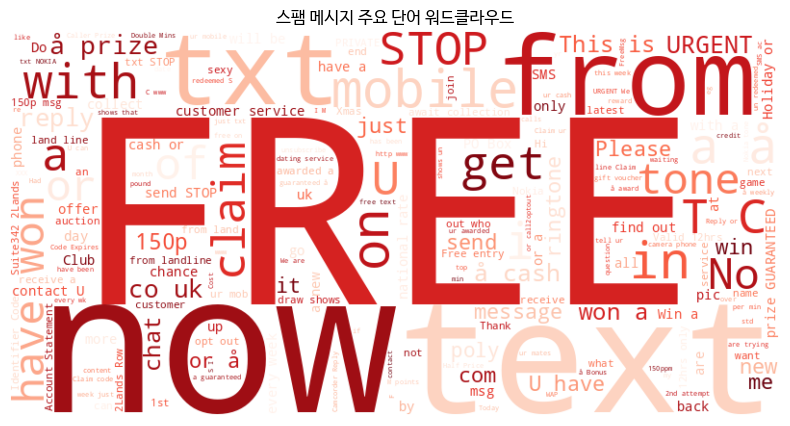


=== 다양한 방법론 비교 요약 ===
TF-IDF 기본: 0.9525
CountVectorizer: 0.9785
TF-IDF (max_features=1000): 0.9677
TF-IDF (ngram_range=(1,2)): 0.9462

=== 최종 모델로 새로운 메시지 분류 ===
'Congratulations! You've won a free ticket!' -> 정상
'Let's have lunch tomorrow' -> 정상
'URGENT: Your bank account needs verification' -> 정상
'Meeting rescheduled to 3 PM' -> 정상


In [21]:
### 4. 워드클라우드로 스팸 메시지 주요 단어 시각화
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 스팸 메시지 추출
spam_messages = ' '.join(df[df['label'] == 'spam']['message'])  # 모든 스팸 메시지를 하나의 문자열로 결합

# 워드클라우드 생성
wordcloud = WordCloud(width=800, height=400,                   # 워드클라우드 크기 설정
                      background_color='white',                # 배경색 흰색으로 설정
                      stopwords=['call', 'to', 'your', 'the', 'and', 'for', 'you', 'our'],  # 추가 불용어 설정
                      colormap='Reds').generate(spam_messages) # 빨간색 계열 컬러맵으로 워드클라우드 생성

# 워드클라우드 시각화
plt.figure(figsize=(10, 5))                                    # 그림 크기 설정
plt.imshow(wordcloud, interpolation='bilinear')               # 워드클라우드 이미지 표시
plt.axis('off')                                               # 축 숨기기
plt.title('스팸 메시지 주요 단어 워드클라우드')                 # 제목 추가
plt.show()                                                    # 그래프 출력

print("\n=== 다양한 방법론 비교 요약 ===")
methods = ['TF-IDF 기본', 'CountVectorizer', 'TF-IDF (max_features=1000)', 'TF-IDF (ngram_range=(1,2))']  # 방법론 이름 목록
accuracies = [
    accuracy_score(y_test, y_pred),          # 기본 TF-IDF 정확도
    accuracy_score(y_test, y_pred_count),    # CountVectorizer 정확도
    accuracy_score(y_test, y_pred_limited),  # 제한된 TF-IDF 정확도
    accuracy_score(y_test, y_pred_ngram)     # n-gram TF-IDF 정확도
]

for method, acc in zip(methods, accuracies):  # 각 방법론과 정확도를 함께 반복
    print(f"{method}: {acc:.4f}")             # 방법론 이름과 정확도 출력

# 가장 성능이 좋은 모델로 새로운 메시지 예측
best_model = model_ngram                      # n-gram 모델을 최종 모델로 선택
best_vectorizer = tfidf_ngram                 # 해당 모델의 벡터라이저 선택

new_messages = ["Congratulations! You've won a free ticket!",  # 테스트할 새 메시지들
                "Let's have lunch tomorrow",
                "URGENT: Your bank account needs verification",
                "Meeting rescheduled to 3 PM"]

new_vec = best_vectorizer.transform(new_messages)              # 새 메시지를 벡터화
predictions = best_model.predict(new_vec)                      # 벡터화된 메시지 분류

print("\n=== 최종 모델로 새로운 메시지 분류 ===")
for msg, pred in zip(new_messages, predictions):               # 각 메시지와 예측 결과를 함께 반복
    print(f"'{msg}' -> {'스팸' if pred == 1 else '정상'}")     # 메시지와 분류 결과 출력